# Phase 4 — Modeling
**Pipeline:** `social_media_analytics`  
**Organization:** Lighthouse PH  
**CRISP-DM Phase:** 4 of 5  

**CRISP-DM Purpose:** Train and compare candidate models using cross-validation on the training set only. The test set is not touched until Phase 5.

---

## 4.0 Setup

In [8]:
import sys, json
from pathlib import Path

PIPELINE_ROOT = Path(".").resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.base import clone

from src.config import (
    TARGET_VALUE, TARGET_BINARY, TARGET_LOG,
    DATA_PROCESSED, FEATURE_COLS_PATH,
    EXPLANATORY_MODEL_PATH, RECOMMENDATION_MODEL_PATH,
    RUNS_DIR, SEED,
)
from src.modeling import build_preprocessor, get_candidate_classifiers, get_candidate_regressors, TwoStageModel
from src.metrics  import report_two_stage

sns.set_style("whitegrid")

# ── Load processed train / test splits (frozen in Phase 3) ───────────────────
df_train = pd.read_csv(DATA_PROCESSED / "train.csv")
df_test  = pd.read_csv(DATA_PROCESSED / "test.csv")

with open(FEATURE_COLS_PATH) as f:
    feat_meta = json.load(f)

all_features  = feat_meta["explanatory"]
pre_pub_cols  = feat_meta["recommendation"]
P99_CAP       = feat_meta["p99_cap"]

print(f"Train : {len(df_train):,} rows")
print(f"Test  : {len(df_test):,} rows  (frozen — not used until Phase 5)")
print(f"Explanatory features   : {len(all_features)}")
print(f"Recommendation features: {len(pre_pub_cols)}")
print(f"p99 cap                : ₱{P99_CAP:,.2f}")

Train : 649 rows
Test  : 163 rows  (frozen — not used until Phase 5)
Explanatory features   : 28
Recommendation features: 17
p99 cap                : ₱353,729.39


In [9]:
# Prepare feature matrices and target vectors
X_train      = df_train[all_features]
y_train_bin  = df_train[TARGET_BINARY]
y_train_log  = df_train[TARGET_LOG]

X_train_rec  = df_train[pre_pub_cols]

# Positive-case subsets for Stage 2 (regressor trained on these only)
pos_mask_train   = y_train_bin.values == 1
X_train_pos      = X_train[pos_mask_train]
X_train_rec_pos  = X_train_rec[pos_mask_train]
y_train_log_pos  = y_train_log[pos_mask_train]

print(f"Stage 1 training set   : {len(X_train):,} posts")
print(f"Stage 2 training set   : {pos_mask_train.sum():,} posts (has_donation=1 only)")
print(f"Positive rate          : {pos_mask_train.mean():.1%}")

Stage 1 training set   : 649 posts
Stage 2 training set   : 417 posts (has_donation=1 only)
Positive rate          : 64.3%


---
## 4.1 Cross-Validation Design

**What is cross-validation?**  
Instead of training a model once, we split the training set into 5 equal folds. For each fold, we train on 4 folds and evaluate on the 1 held-out fold. This gives us 5 performance estimates, and we average them. The result is a reliable, low-variance estimate of how well a model generalises — without ever touching the test set.

| Stage | CV strategy | Scoring metric | Why |
|---|---|---|---|
| Stage 1 (classifier) | `StratifiedKFold(5)` | **ROC AUC** | Each fold preserves the 64/36 class balance; AUC measures separation ability |
| Stage 2 (regressor) | `KFold(5)` on positive cases | **R²** | Measures how much variance in log-donation-value the model explains |

---
## 4.2 Stage 1 — Classifier (Has Donation?)

We compare two candidate classifiers on the full training set:
- **Logistic Regression** — linear, fast, coefficients are directly interpretable
- **Random Forest** — ensemble of decision trees, typically higher performance, explained via feature importance

In [10]:
def run_cv_classifiers(X, y, label=""):
    """Cross-validate classifier candidates. Returns (cv_results_dict, best_name, best_pipe)."""
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols     = X.select_dtypes(exclude=np.number).columns.tolist()
    preprocessor = build_preprocessor(numeric_cols, cat_cols)
    candidates   = get_candidate_classifiers(preprocessor)
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    results = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}

    best_name = max(results, key=lambda k: results[k]["mean"])
    best_pipe = candidates[best_name]
    return results, best_name, best_pipe


print("=" * 55)
print("EXPLANATORY MODEL — Stage 1 CV (all features)")
print("=" * 55)
clf_results, best_clf_name, best_clf_pipe = run_cv_classifiers(X_train, y_train_bin)
for name, r in clf_results.items():
    marker = " ◄ SELECTED" if name == best_clf_name else ""
    print(f"  {name:20s}  ROC AUC = {r['mean']:.4f} ± {r['std']:.4f}{marker}")

print()
print("=" * 55)
print("RECOMMENDATION MODEL — Stage 1 CV (pre-pub features only)")
print("=" * 55)
clf_results_rec, best_clf_rec_name, best_clf_rec_pipe = run_cv_classifiers(X_train_rec, y_train_bin)
for name, r in clf_results_rec.items():
    marker = " ◄ SELECTED" if name == best_clf_rec_name else ""
    print(f"  {name:20s}  ROC AUC = {r['mean']:.4f} ± {r['std']:.4f}{marker}")

EXPLANATORY MODEL — Stage 1 CV (all features)
  LogReg                ROC AUC = 0.9737 ± 0.0114
  RandomForest          ROC AUC = 0.9764 ± 0.0125 ◄ SELECTED

RECOMMENDATION MODEL — Stage 1 CV (pre-pub features only)
  LogReg                ROC AUC = 0.8976 ± 0.0359 ◄ SELECTED
  RandomForest          ROC AUC = 0.8969 ± 0.0279


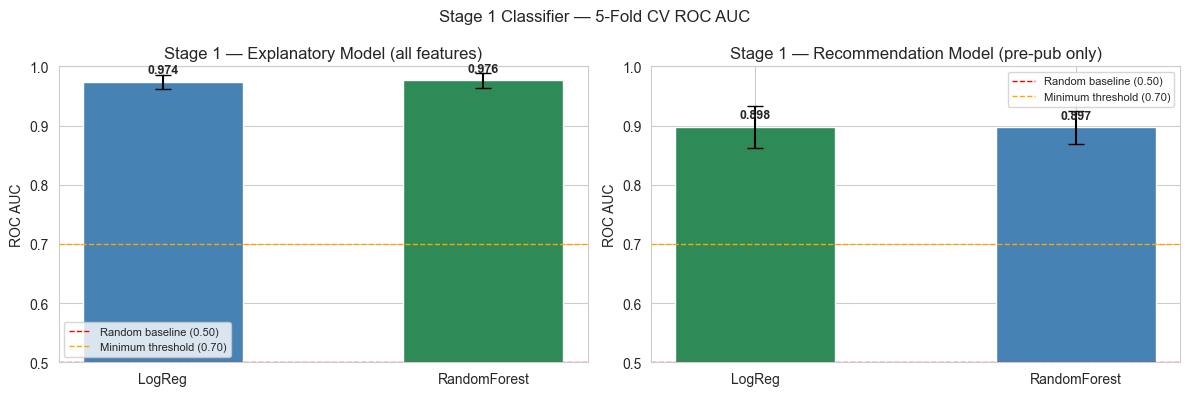

In [11]:
# Visualise Stage 1 CV scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, results, title in [
    (axes[0], clf_results,     "Explanatory Model (all features)"),
    (axes[1], clf_results_rec, "Recommendation Model (pre-pub only)"),
]:
    names  = list(results.keys())
    means  = [results[n]["mean"] for n in names]
    stds   = [results[n]["std"]  for n in names]
    colors = ["steelblue" if n != max(results, key=lambda k: results[k]["mean"]) else "seagreen" for n in names]
    bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, width=0.5)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, color="red", linestyle="--", lw=1, label="Random baseline (0.50)")
    ax.axhline(0.7, color="orange", linestyle="--", lw=1, label="Minimum threshold (0.70)")
    ax.set_ylabel("ROC AUC")
    ax.set_title(f"Stage 1 — {title}")
    ax.legend(fontsize=8)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01, f"{mean:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Stage 1 Classifier — 5-Fold CV ROC AUC", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4.3 Stage 2 — Regressor (How Much Donation Value?)

Stage 2 trains on **positive cases only** (posts that generated any donation value). The target is `log_donation_value = log1p(estimated_donation_value_php)`. R² measures the proportion of variance explained — 0.0 means the model does no better than always predicting the mean; 1.0 is a perfect fit.

In [12]:
def run_cv_regressors(X_pos, y_pos, label=""):
    """Cross-validate regressor candidates on positive cases. Returns (cv_results_dict, best_name, best_pipe)."""
    numeric_cols = X_pos.select_dtypes(include=np.number).columns.tolist()
    cat_cols     = X_pos.select_dtypes(exclude=np.number).columns.tolist()
    preprocessor = build_preprocessor(numeric_cols, cat_cols)
    candidates   = get_candidate_regressors(preprocessor)
    cv           = KFold(n_splits=5, shuffle=True, random_state=SEED)

    results = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X_pos, y_pos, cv=cv, scoring="r2", n_jobs=-1)
        results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}

    best_name = max(results, key=lambda k: results[k]["mean"])
    best_pipe = candidates[best_name]
    return results, best_name, best_pipe


print("=" * 55)
print("EXPLANATORY MODEL — Stage 2 CV (positive cases only)")
print("=" * 55)
reg_results, best_reg_name, best_reg_pipe = run_cv_regressors(X_train_pos, y_train_log_pos)
for name, r in reg_results.items():
    marker = " ◄ SELECTED" if name == best_reg_name else ""
    print(f"  {name:20s}  R² = {r['mean']:.4f} ± {r['std']:.4f}{marker}")

print()
print("=" * 55)
print("RECOMMENDATION MODEL — Stage 2 CV (pre-pub only, positive cases)")
print("=" * 55)
reg_results_rec, best_reg_rec_name, best_reg_rec_pipe = run_cv_regressors(X_train_rec_pos, y_train_log_pos)
for name, r in reg_results_rec.items():
    marker = " ◄ SELECTED" if name == best_reg_rec_name else ""
    print(f"  {name:20s}  R² = {r['mean']:.4f} ± {r['std']:.4f}{marker}")

EXPLANATORY MODEL — Stage 2 CV (positive cases only)
  Ridge                 R² = 0.6127 ± 0.0986
  RandomForest          R² = 0.6838 ± 0.0444 ◄ SELECTED

RECOMMENDATION MODEL — Stage 2 CV (pre-pub only, positive cases)
  Ridge                 R² = 0.4424 ± 0.0764 ◄ SELECTED
  RandomForest          R² = 0.3784 ± 0.0209


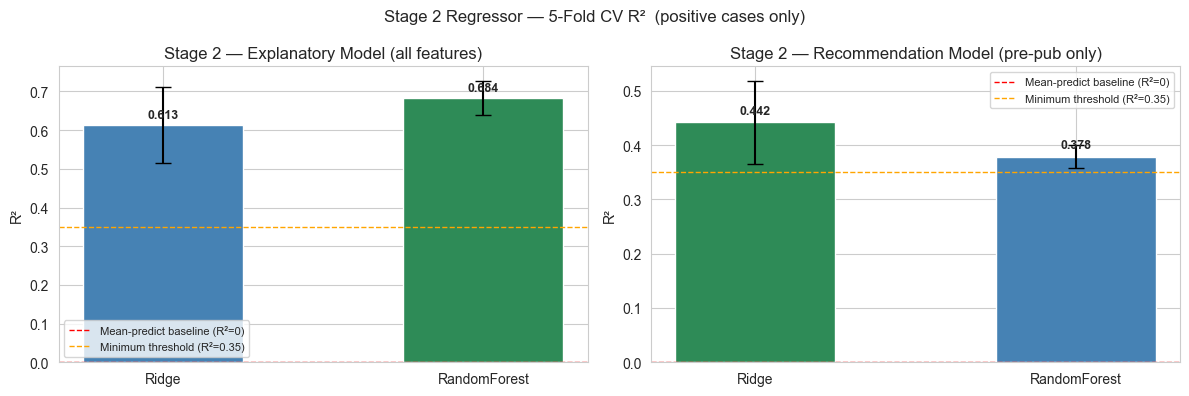

In [13]:
# Visualise Stage 2 CV scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, results, title in [
    (axes[0], reg_results,     "Explanatory Model (all features)"),
    (axes[1], reg_results_rec, "Recommendation Model (pre-pub only)"),
]:
    names  = list(results.keys())
    means  = [results[n]["mean"] for n in names]
    stds   = [results[n]["std"]  for n in names]
    colors = ["steelblue" if n != max(results, key=lambda k: results[k]["mean"]) else "seagreen" for n in names]
    bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, width=0.5)
    ax.axhline(0.0,  color="red",    linestyle="--", lw=1, label="Mean-predict baseline (R²=0)")
    ax.axhline(0.35, color="orange", linestyle="--", lw=1, label="Minimum threshold (R²=0.35)")
    ax.set_ylabel("R²")
    ax.set_title(f"Stage 2 — {title}")
    ax.legend(fontsize=8)
    for bar, mean in zip(bars, means):
        y_offset = mean + 0.01 if mean >= 0 else mean - 0.04
        ax.text(bar.get_x() + bar.get_width()/2, y_offset, f"{mean:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Stage 2 Regressor — 5-Fold CV R²  (positive cases only)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4.4 Assemble & Fit Final Models

The best classifier and regressor from CV are cloned and refit on the **full training set**. This is the final model that will be evaluated in Phase 5.

In [14]:
def build_two_stage(X_all, y_bin, y_log,
                    best_clf_pipe, best_reg_pipe, label):
    """Clone best CV candidates, refit on full training data, return fitted TwoStageModel."""
    print(f"Fitting {label}...")
    print(f"  Classifier : {type(best_clf_pipe.named_steps["model"]).__name__}")
    print(f"  Regressor  : {type(best_reg_pipe.named_steps["model"]).__name__}")

    clf = clone(best_clf_pipe)
    reg = clone(best_reg_pipe)

    model = TwoStageModel(classifier=clf, regressor=reg)
    # Pass full y_log — TwoStageModel.fit() filters to positive cases internally
    model.fit(X_all, y_bin, y_log)
    print(f"  Done.")
    return model


# Explanatory model (all features)
expl_model = build_two_stage(
    X_train, y_train_bin, y_train_log,
    best_clf_pipe, best_reg_pipe,
    "Explanatory Model"
)

print()

# Recommendation model (pre-pub features only)
rec_model = build_two_stage(
    X_train_rec, y_train_bin, y_train_log,
    best_clf_rec_pipe, best_reg_rec_pipe,
    "Recommendation Model"
)


Fitting Explanatory Model...
  Classifier : RandomForestClassifier
  Regressor  : RandomForestRegressor
  Done.

Fitting Recommendation Model...
  Classifier : LogisticRegression
  Regressor  : Ridge
  Done.


---
## 4.5 Feature Importance Analysis

**What is feature importance?**  
Random Forest builds hundreds of decision trees and tracks which features are most frequently used to split the data at high-information nodes. A feature's importance score (0–1, summing to 1) reflects how much it reduces prediction error across all trees. Higher = more influential.

This tells us *which post characteristics matter most* for predicting whether a post generates donation value.

  Stage 1 Feature Importance — Recommendation Model (pre-pub only): feature importances not available for LogisticRegression


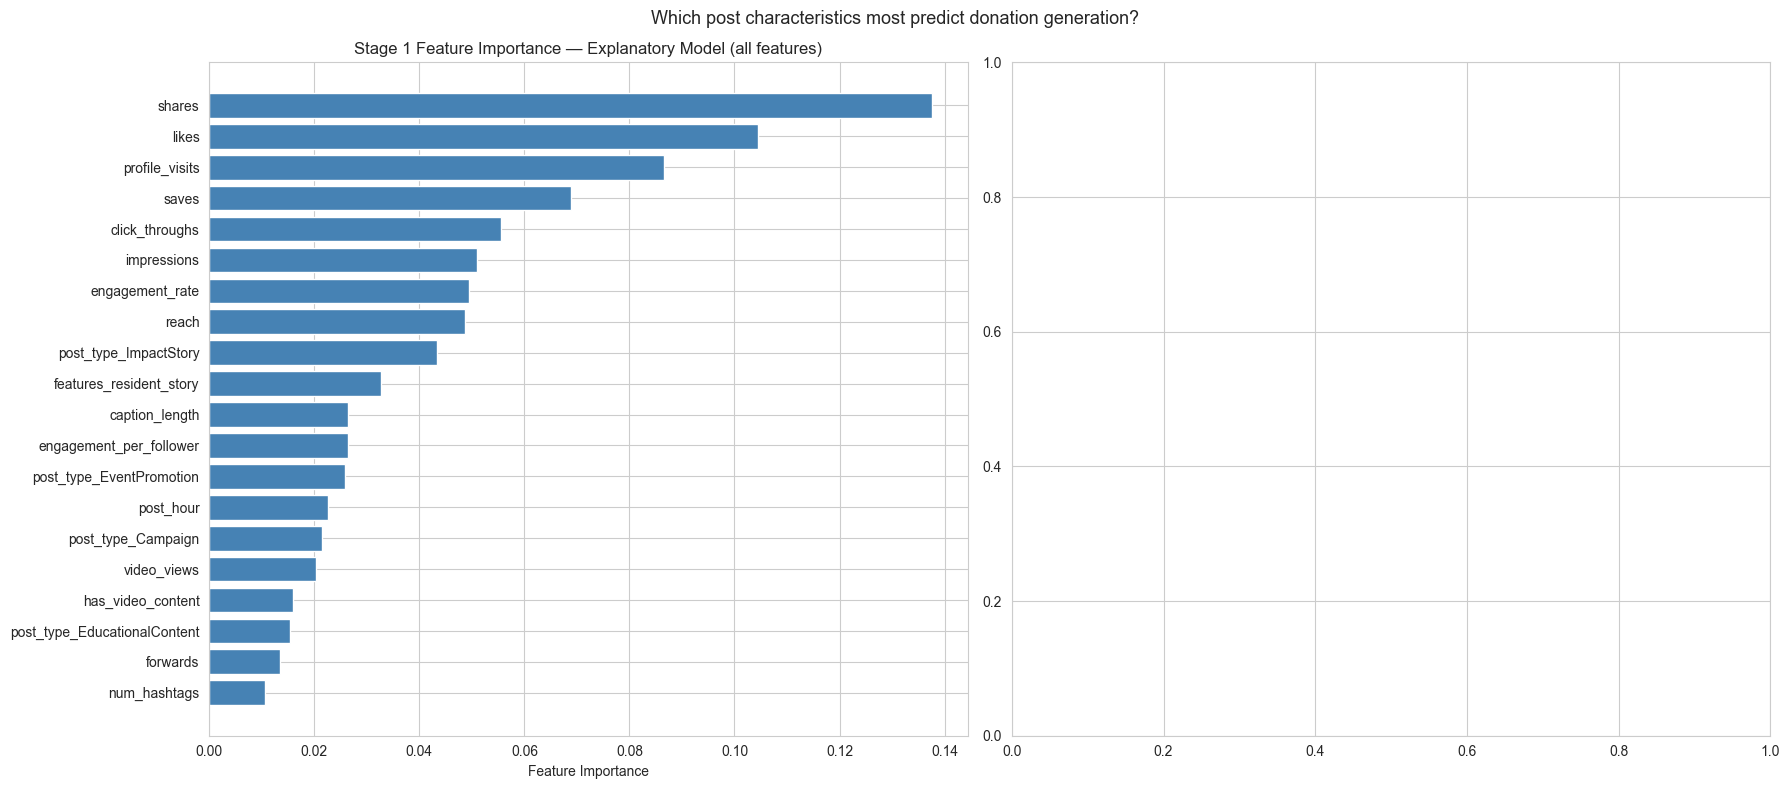

In [15]:
def plot_feature_importance(model, feature_names, title, top_n=20, ax=None):
    clf_step = model.classifier.named_steps["model"]
    if not hasattr(clf_step, "feature_importances_"):
        print(f"  {title}: feature importances not available for {type(clf_step).__name__}")
        return

    # Get feature names after OHE expansion
    try:
        prep  = model.classifier.named_steps["prep"]
        names = list(prep.get_feature_names_out())
        # Strip sklearn prefixes like "num__" and "cat__"
        names = [n.split("__")[-1] for n in names]
    except Exception:
        names = feature_names[:len(clf_step.feature_importances_)]

    imp_df = (
        pd.DataFrame({"feature": names, "importance": clf_step.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))

    colors = ["steelblue"] * len(imp_df)
    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=colors[::-1])
    ax.set_xlabel("Feature Importance")
    ax.set_title(title)
    return imp_df


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

imp_expl = plot_feature_importance(
    expl_model, all_features,
    "Stage 1 Feature Importance — Explanatory Model (all features)",
    top_n=20, ax=axes[0]
)

imp_rec = plot_feature_importance(
    rec_model, pre_pub_cols,
    "Stage 1 Feature Importance — Recommendation Model (pre-pub only)",
    top_n=20, ax=axes[1]
)

plt.suptitle("Which post characteristics most predict donation generation?", fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Top 10 features — clean text summary for use in presentation
if imp_expl is not None:
    print("Top 10 features (Explanatory Model — Stage 1 classifier):")
    print(imp_expl.head(10).to_string(index=False))

print()

if imp_rec is not None:
    print("Top 10 features (Recommendation Model — pre-pub only):")
    print(imp_rec.head(10).to_string(index=False))

Top 10 features (Explanatory Model — Stage 1 classifier):
                feature  importance
                 shares    0.137524
                  likes    0.104480
         profile_visits    0.086499
                  saves    0.068900
         click_throughs    0.055506
            impressions    0.051039
        engagement_rate    0.049413
                  reach    0.048697
  post_type_ImpactStory    0.043285
features_resident_story    0.032723



---
## 4.6 Training-Set Sanity Check

Before evaluating on the test set in Phase 5, we do a quick sanity check on the training set to confirm the models have learned meaningful patterns (not all zeros, reasonable score distributions).

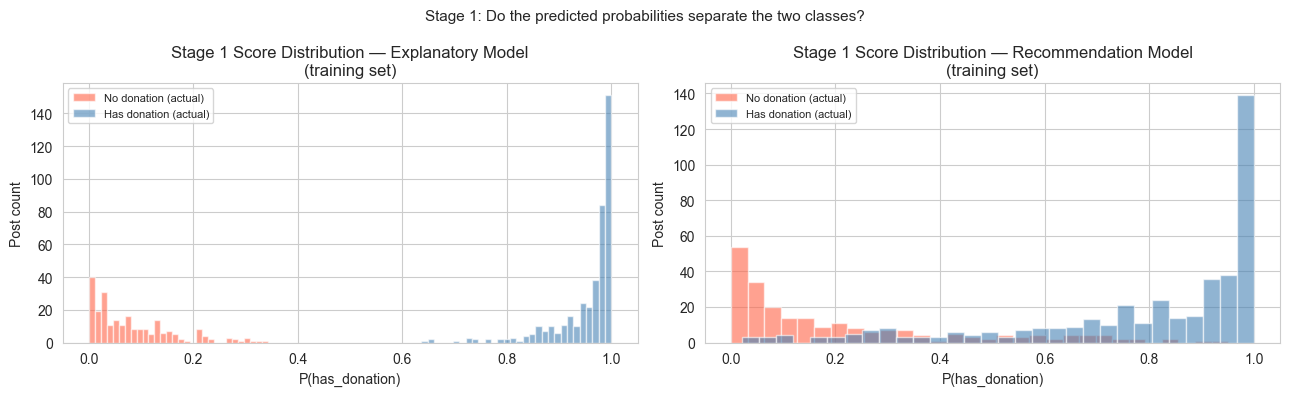

Mean P(has_donation) for actual negatives (should be low):
  Explanatory  : 0.083
  Recommendation: 0.205
Mean P(has_donation) for actual positives (should be high):
  Explanatory  : 0.956
  Recommendation: 0.794


In [17]:
# Stage 1: predicted probability distribution on training set
p_train_expl = expl_model.predict_proba_stage1(X_train)
p_train_rec  = rec_model.predict_proba_stage1(X_train_rec)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, probs, y_true, title in [
    (axes[0], p_train_expl, y_train_bin, "Explanatory Model"),
    (axes[1], p_train_rec,  y_train_bin, "Recommendation Model"),
]:
    ax.hist(probs[y_true == 0], bins=30, alpha=0.6, label="No donation (actual)", color="tomato")
    ax.hist(probs[y_true == 1], bins=30, alpha=0.6, label="Has donation (actual)", color="steelblue")
    ax.set_xlabel("P(has_donation)")
    ax.set_ylabel("Post count")
    ax.set_title(f"Stage 1 Score Distribution — {title}\n(training set)")
    ax.legend(fontsize=8)

plt.suptitle("Stage 1: Do the predicted probabilities separate the two classes?", fontsize=11)
plt.tight_layout()
plt.show()

print("Mean P(has_donation) for actual negatives (should be low):")
print(f"  Explanatory  : {p_train_expl[y_train_bin==0].mean():.3f}")
print(f"  Recommendation: {p_train_rec[y_train_bin==0].mean():.3f}")
print("Mean P(has_donation) for actual positives (should be high):")
print(f"  Explanatory  : {p_train_expl[y_train_bin==1].mean():.3f}")
print(f"  Recommendation: {p_train_rec[y_train_bin==1].mean():.3f}")

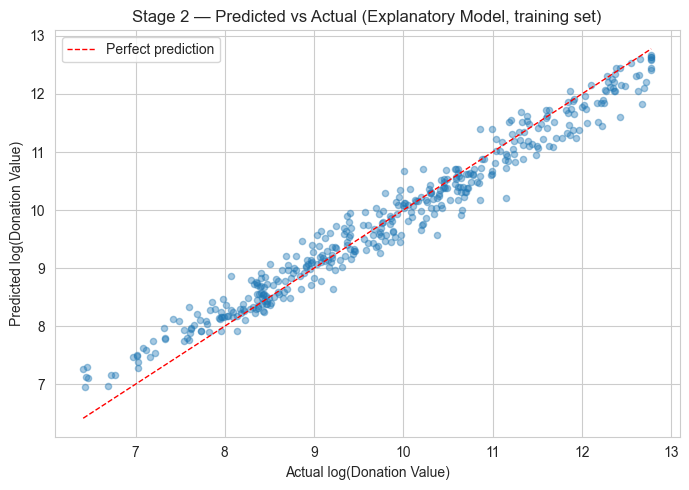

In [18]:
# Stage 2: predicted vs actual on positive training cases
log_pred_train = expl_model.predict_stage2(X_train_pos)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_train_log_pos, log_pred_train, alpha=0.4, s=20)
lims = [min(y_train_log_pos.min(), log_pred_train.min()),
        max(y_train_log_pos.max(), log_pred_train.max())]
ax.plot(lims, lims, "r--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual log(Donation Value)")
ax.set_ylabel("Predicted log(Donation Value)")
ax.set_title("Stage 2 — Predicted vs Actual (Explanatory Model, training set)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4.7 Save Model Artifacts

In [19]:
from datetime import datetime, timezone
from sklearn.metrics import roc_auc_score

EXPLANATORY_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Save model artifacts
joblib.dump({"model": expl_model, "feature_cols": all_features},  EXPLANATORY_MODEL_PATH)
joblib.dump({"model": rec_model,  "feature_cols": pre_pub_cols},  RECOMMENDATION_MODEL_PATH)

print(f"Saved → {EXPLANATORY_MODEL_PATH}")
print(f"Saved → {RECOMMENDATION_MODEL_PATH}")

# CV summary for run metadata
expl_clf_auc = clf_results[best_clf_name]["mean"]
expl_reg_r2  = reg_results[best_reg_name]["mean"]
rec_clf_auc  = clf_results_rec[best_clf_rec_name]["mean"]
rec_reg_r2   = reg_results_rec[best_reg_rec_name]["mean"]

run_meta = {
    "trained_at"              : datetime.now(timezone.utc).isoformat(),
    "n_train"                 : int(len(df_train)),
    "n_test"                  : int(len(df_test)),
    "p99_cap_php"             : P99_CAP,
    "explanatory": {
        "classifier"          : best_clf_name,
        "regressor"           : best_reg_name,
        "cv_stage1_roc_auc"   : round(expl_clf_auc, 4),
        "cv_stage2_r2"        : round(expl_reg_r2,  4),
        "n_features"          : len(all_features),
    },
    "recommendation": {
        "classifier"          : best_clf_rec_name,
        "regressor"           : best_reg_rec_name,
        "cv_stage1_roc_auc"   : round(rec_clf_auc, 4),
        "cv_stage2_r2"        : round(rec_reg_r2,  4),
        "n_features"          : len(pre_pub_cols),
    },
}

with open(RUNS_DIR / "latest_run.json", "w") as f:
    json.dump(run_meta, f, indent=2)

print(f"\nRun metadata saved → {RUNS_DIR / 'latest_run.json'}")
print(json.dumps(run_meta, indent=2))

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\models\explanatory_model.joblib
Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\models\recommendation_model.joblib

Run metadata saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\runs\latest_run.json
{
  "trained_at": "2026-04-08T00:08:26.525444+00:00",
  "n_train": 649,
  "n_test": 163,
  "p99_cap_php": 353729.38719999924,
  "explanatory": {
    "classifier": "RandomForest",
    "regressor": "RandomForest",
    "cv_stage1_roc_auc": 0.9764,
    "cv_stage2_r2": 0.6838,
    "n_features": 28
  },
  "recommendation": {
    "classifier": "LogReg",
    "regressor": "Ridge",
    "cv_stage1_roc_auc": 0.8976,
    "cv_stage2_r2": 0.4424,
    "n_features": 17
  }
}


---
## 4.8 Phase 4 Summary

| | Explanatory Model | Recommendation Model |
|---|---|---|
| **Stage 1 classifier** | Best CV candidate | Best CV candidate |
| **Stage 1 ROC AUC (CV)** | See run metadata | See run metadata |
| **Stage 2 regressor** | Best CV candidate | Best CV candidate |
| **Stage 2 R² (CV)** | See run metadata | See run metadata |
| **Features** | All (pre-pub + post-pub) | Pre-pub only |
| **Artifact** | `explanatory_model.joblib` | `recommendation_model.joblib` |

### What happens in Phase 5
- Both models are evaluated on the **frozen test set** for the first and only time
- Final metrics (ROC AUC, R², RMSE in PHP) are reported vs the success thresholds defined in Phase 1
- A go/no-go decision is made for each artifact
- Business recommendations are drawn from the feature importance analysis above

**Phase 4 status: COMPLETE. Models trained and artifacts saved. Proceed to Phase 5 — Evaluation.**